Name: Fateh Noor
CMS ID: 023-24-0110
Section: D
Github:


In [2]:
#task 1
import pandas as pd 
import numpy as np 
df=pd.read_csv("clean_churn.csv")
print(df.shape)
print(df.dtypes)
print("Missing values in each column:\n", df.isnull().sum())

(7043, 20)
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
Missing values in each column:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCh

#task 2
The goal is to predict whether a customer will churn (leave the service) based on their demographic and service-related information. This is important for the business because identifying customers who are likely to churn allows the company to take preventive actions and improve customer retention.

In [3]:
#task 3
y=df['Churn'].map(
    {'Yes':1,'No':0}
)
x=df.drop(['Churn'],axis=1)

I used one-hot encoding for the categorical columns because most of them are nominal categories with no meaningful numerical order. drop_first=True removes one category from each encoded variable to avoid redundant columns, while the already numeric columns remain unchanged.

In [4]:
#task 4
x=pd.get_dummies(x,drop_first=True)

In [5]:
#task 5
print(x.dtypes)

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

In [6]:
#task 6
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
                        x,y,
                        test_size=0.2,
                        random_state=42,
                        stratify=y)

stratify=y is a sensible choice because the Churn classes are imbalanced, with fewer customers in the Churn class than the Not Churn class. Stratification keeps approximately the same proportion of Churn and Not Churn customers in both the training and testing sets, making the evaluation more reliable.

In [7]:
#task 7
print("Shape of x_train: ",x_train.shape)
print("Shape of y_train: ",y_train.shape)
print("Shape of x_test: ",x_test.shape)
print("Shape of y_test: ",y_test.shape)

Shape of x_train:  (5634, 30)
Shape of y_train:  (5634,)
Shape of x_test:  (1409, 30)
Shape of y_test:  (1409,)


In [8]:
#task 8
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(random_state=42)
tree.fit(x_train,y_train)
pred_train=tree.predict(x_train)
pred_test=tree.predict(x_test)
print("Prediction on training data: ",pred_train)
print("Prediction on test data: ",pred_test)

Prediction on training data:  [0 0 0 ... 1 0 0]
Prediction on test data:  [0 1 0 ... 0 0 0]


In [9]:
#task 9
print("Depth of tree: ",tree.get_depth())

Depth of tree:  24


In [10]:
#task 10
from sklearn.metrics import (accuracy_score,precision_score,
                             recall_score,f1_score)
accuracy=accuracy_score(y_test,pred_test)
precision=precision_score(y_test,pred_test)
recall=recall_score(y_test,pred_test)
f1=f1_score(y_test,pred_test)
print("Accuracy on test data: ",round(accuracy,4))
print("Precision on test data: ",round(precision,4))
print("Recall on training data: ",round(recall,4))
print("F1 Score on training data: ",round(f1,4))

Accuracy on test data:  0.7417
Precision on test data:  0.5139
Recall on training data:  0.4947
F1 Score on training data:  0.5041


| Metric | Test Set Result |
|---|---:|
| Accuracy | 0.7417 |
| Precision | 0.5139 |
| Recall | 0.4947 |
| F1-score | 0.5041 |

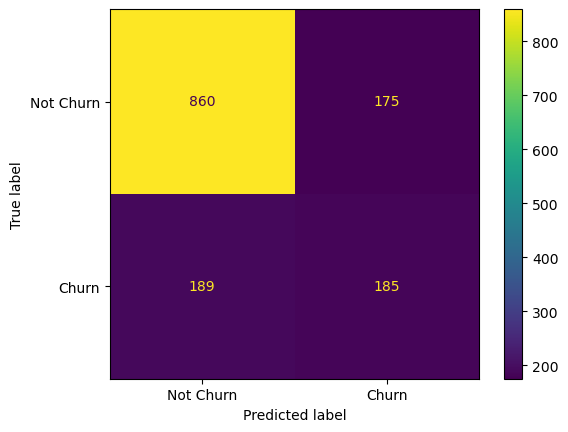

In [11]:
#task 11
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,pred_test)
ConfusionMatrixDisplay(cm,display_labels=['Not Churn', 'Churn']).plot()

In [12]:
#task 13
accuracy_train=accuracy_score(y_train,pred_train)
print("Accuracy on training data: ",round(accuracy_train,4))
print("Accuracy on test data: ",round(accuracy,4))

Accuracy on training data:  0.998
Accuracy on test data:  0.7417


In [13]:
tree2=DecisionTreeClassifier(max_depth=2,random_state=42)
tree4=DecisionTreeClassifier(max_depth=4,random_state=42)
tree6=DecisionTreeClassifier(max_depth=6,random_state=42)
tree8=DecisionTreeClassifier(max_depth=8,random_state=42)
tree10=DecisionTreeClassifier(max_depth=10,random_state=42)
tree2.fit(x_train,y_train)
tree4.fit(x_train,y_train)
tree6.fit(x_train,y_train)
tree8.fit(x_train,y_train)
tree10.fit(x_train,y_train)
max_depth = [2, 4, 6, 8, 10]
train_accuracy = [
    accuracy_score(y_train, tree2.predict(x_train)),
    accuracy_score(y_train, tree4.predict(x_train)),
    accuracy_score(y_train, tree6.predict(x_train)),
    accuracy_score(y_train, tree8.predict(x_train)),
    accuracy_score(y_train, tree10.predict(x_train))
]
test_accuracy = [
    accuracy_score(y_test, tree2.predict(x_test)),
    accuracy_score(y_test, tree4.predict(x_test)),
    accuracy_score(y_test, tree6.predict(x_test)),
    accuracy_score(y_test, tree8.predict(x_test)),
    accuracy_score(y_test, tree10.predict(x_test))
]

print("Accuracy on training data for max_depth=2:",round(train_accuracy[0],4))
print("Accuracy on training data for max_depth=4:",round(train_accuracy[1],4))
print("Accuracy on training data for max_depth=6:",round(train_accuracy[2],4))
print("Accuracy on training data for max_depth=8:",round(train_accuracy[3],4))
print("Accuracy on training data for max_depth=10:",round(train_accuracy[4],4))
print("Accuracy on test data for max_depth=2:",round(test_accuracy[0],4))
print("Accuracy on test data for max_depth=4:",round(test_accuracy[1],4))
print("Accuracy on test data for max_depth=6:",round(test_accuracy[2],4))
print("Accuracy on test data for max_depth=8:",round(test_accuracy[3],4))
print("Accuracy on test data for max_depth=10:",round(test_accuracy[4],4))

Accuracy on training data for max_depth=2: 0.7911
Accuracy on training data for max_depth=4: 0.7925
Accuracy on training data for max_depth=6: 0.8071
Accuracy on training data for max_depth=8: 0.8349
Accuracy on training data for max_depth=10: 0.8722
Accuracy on test data for max_depth=2: 0.7871
Accuracy on test data for max_depth=4: 0.7956
Accuracy on test data for max_depth=6: 0.797
Accuracy on test data for max_depth=8: 0.78
Accuracy on test data for max_depth=10: 0.7559


| Max Depth | Training Accuracy | Test Accuracy |
|---:|---:|---:|
| 2  | 0.7911 | 0.7871 |
| 4  | 0.7925 | 0.7956 |
| 6  | 0.8071 | 0.7970 |
| 8  | 0.8349 | 0.7800 |
| 10 | 0.8722 | 0.7559 |

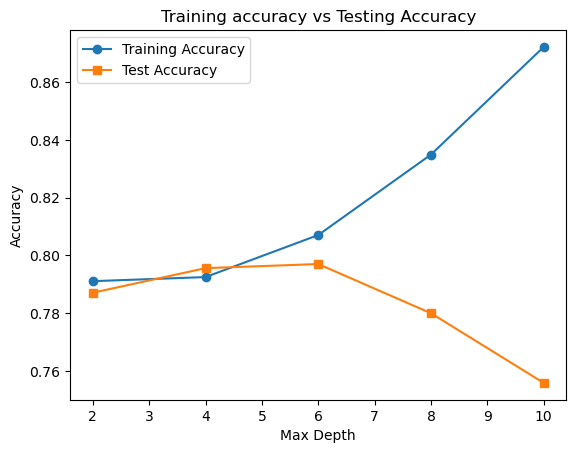

In [14]:
#task 15
import matplotlib.pyplot as plt
plt.plot(max_depth,train_accuracy,marker='o',label='Training Accuracy')
plt.plot(max_depth,test_accuracy,marker='s',label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Training accuracy vs Testing Accuracy')
plt.legend()
plt.show()

The model starts to overfit at roughly max_depth = 6. After depth 6, training accuracy continues to increase while test accuracy decreases, creating a growing gap between the two. This indicates that the tree is fitting the training data too closely and losing its ability to generalize to unseen data.

#task 16
I selected max_depth = 4 as the best model because it provides a high test accuracy of 0.7956 while keeping the training and test accuracies very close. Although max_depth = 6 has a slightly higher test accuracy (0.7970), depth 4 is simpler and is less likely to overfit as the tree becomes deeper.

In [15]:
#task 17
tree_best=DecisionTreeClassifier(max_depth=4)
tree_best.fit(x_train,y_train)
pred_best=tree_best.predict(x_test)
accuracy_best=accuracy_score(y_test,pred_best)
precision_best=precision_score(y_test,pred_best)
recall_best=recall_score(y_test,pred_best)
f1_best=f1_score(y_test,pred_best)
print("Accuracy on test data or best selected model: ",round(accuracy_best,4))
print("Precision on test data or best selected model: ",round(precision_best,4))
print("Recall on test data or best selected model: ",round(recall_best,4))
print("F1-Score on test data or best selected model: ",round(f1_best,4))

Accuracy on test data or best selected model:  0.7956
Precision on test data or best selected model:  0.6443
Recall on test data or best selected model:  0.5134
F1-Score on test data or best selected model:  0.5714


| Metric | Baseline | Depth=4 |
|---:|---:|---:|
| Accuracy | 0.7417 | 0.7956 |
| Precision | 0.5139 | 0.6443 |
| Recall | 0.4947 | 0.5134 |
| F1 Score | 0.5041 | 0.5714 |

In [16]:
#task 18
tree_entropy=DecisionTreeClassifier(criterion='entropy')
tree_entropy.fit(x_train,y_train)
pred_entropy=tree_entropy.predict(x_test)
accuracy_entropy=accuracy_score(y_test,pred_entropy)
precision_entropy=precision_score(y_test,pred_entropy)
recall_entropy=recall_score(y_test,pred_entropy)
f1_entropy=f1_score(y_test,pred_entropy)
print("Accuracy on test data for model with critera Entropy:",round(accuracy_entropy,4))
print("Precision on test data for model with critera Entropy:",round(precision_entropy,4))
print("Recall on test data for model with critera Entropy:",round(recall_entropy,4))
print("F1-Score on test data for model with critera Entropy:",round(f1_entropy,4))

Accuracy on test data for model with critera Entropy: 0.741
Precision on test data for model with critera Entropy: 0.5119
Recall on test data for model with critera Entropy: 0.516
F1-Score on test data for model with critera Entropy: 0.514


| Metric | Baseline | Criterion='Entropy' |
|---:|---:|---:|
| Accuracy | 0.7417 | 0.7346 |
| Precision | 0.5139 | 0.5 |
| Recall | 0.4947 | 0.4893 |
| F1 Score | 0.5041 | 0.4946 |

The entropy-based Decision Tree performed slightly worse than the baseline Gini-based tree on all four evaluation metrics. Its accuracy decreased from 0.7417 to 0.7346, while precision, recall, and F1-score also decreased, so the entropy criterion did not improve the model's performance on the test set.

In [17]:
#task 19
for column,importance in zip(x_train,tree_best.feature_importances_):
    print(column,": ",round(importance,4))

SeniorCitizen :  0.0
tenure :  0.4627
MonthlyCharges :  0.0
TotalCharges :  0.0233
gender_Male :  0.0
Partner_Yes :  0.0
Dependents_Yes :  0.0
PhoneService_Yes :  0.0
MultipleLines_No phone service :  0.0077
MultipleLines_Yes :  0.0148
InternetService_Fiber optic :  0.3925
InternetService_No :  0.0
OnlineSecurity_No internet service :  0.0
OnlineSecurity_Yes :  0.0
OnlineBackup_No internet service :  0.0
OnlineBackup_Yes :  0.0
DeviceProtection_No internet service :  0.0
DeviceProtection_Yes :  0.0
TechSupport_No internet service :  0.0227
TechSupport_Yes :  0.0061
StreamingTV_No internet service :  0.0
StreamingTV_Yes :  0.0
StreamingMovies_No internet service :  0.0191
StreamingMovies_Yes :  0.0
Contract_One year :  0.0
Contract_Two year :  0.0215
PaperlessBilling_Yes :  0.0
PaymentMethod_Credit card (automatic) :  0.0
PaymentMethod_Electronic check :  0.0296
PaymentMethod_Mailed check :  0.0


The five most important features are tenure (0.4627), InternetService_Fiber optic (0.3925), PaymentMethod_Electronic check (0.0296), TotalCharges (0.0233), and StreamingTV_No internet service (0.0227). These features have the highest feature importance values and contributed the most to the Decision Tree's predictions.

#task 20
The top features mostly agree with the patterns found in Lab 2's EDA. In particular, tenure and InternetService were important in both analyses, supporting the finding that customer tenure and type of internet service are related to churn.

#task 21
I selected the Decision Tree with max_depth = 4 as the final model. It achieved a test accuracy of 0.7956, precision of 0.6443, recall of 0.5134, and F1-score of 0.5714. The model performed better than the baseline, but its recall is still relatively low, meaning it misses some customers who actually churn. Another limitation is that the Decision Tree can overfit when its depth becomes too large.

#task 22
If I had more time, I would try a different algorithm such as Random Forest or Logistic Regression and compare its performance with the Decision Tree. I would also explore more feature engineering and handle the class imbalance using techniques such as class weights or resampling, which could potentially improve recall for the Churn class.

In [18]:
def entropy(p,n):
    if p==0 or n==0:
        return 0
    return -(p/(p+n))*np.log2(p/(p+n))-(n/(p+n))*np.log2(n/(p+n))
counts=df['Churn'].value_counts()
p=counts['Yes']
n=counts['No']
total=p+n
total_entropy=entropy(p,n)
def column_ig(data,col,total,total_entropy):
    weight_entropy=0
    for category in data[col].unique():
        sub=data[data[col]==category]
        counts_sub=sub['Churn'].value_counts()
        p_sub=counts_sub.get('Yes',0)
        n_sub=counts_sub.get('No',0)
        entropy_sub=entropy(p_sub,n_sub)
        weight_entropy+=((p_sub+n_sub)/total)*entropy_sub
    information_gain=total_entropy-weight_entropy
    return information_gain

In [19]:
def bestThreshold(data,column,total,total_entropy):
    max_ig=0
    best_threshold=None
    values=sorted(data[column].unique())
    for i in range(len(values)-1):
        threshold=(values[i]+values[i+1])/2 
        left=data[data[column]<=threshold]
        right=data[data[column]>threshold]
        left_count=left['Churn'].value_counts()
        p_left=left_count.get('Yes', 0)
        n_left=left_count.get('No', 0)
        right_count=right['Churn'].value_counts()
        p_right=right_count.get('Yes', 0)
        n_right=right_count.get('No', 0)
        left_entropy=entropy(p_left,n_left)
        right_entropy=entropy(p_right,n_right)
        weighted_entropy=((p_left+n_left)/total)*left_entropy+((p_right+n_right)/total)*right_entropy
        information_gain=total_entropy-weighted_entropy
        if information_gain > max_ig:
            max_ig = information_gain
            best_threshold = threshold
    return best_threshold, max_ig

In [20]:
def best_split(data,total,total_entropy):
    best_column=None
    best_threshold=None
    best_ig=-1
    threshold=0
    print("Informatin gain of this split: ")
    for col in data.drop(columns=['Churn']).columns:
        if data[col].dtype=='object':
            ig=column_ig(data,col,total,total_entropy)
            threshold = None    
        else:
            threshold,ig=bestThreshold(data,col,total,total_entropy)
        print(col,": ",round(ig,2))
        if ig>best_ig:
            best_ig=ig
            best_column=col
            best_threshold=threshold
    print("Best Feature: ",best_column)
    print("Best Gain: ",round(best_ig,2))
    return best_column,best_threshold,best_ig


In [21]:
def build_tree(data,depth=0,max_depth=4):
    counts=data['Churn'].value_counts()
    p=counts.get('Yes',0)
    n=counts.get('No',0)
    total=p+n 
    total_entropy=entropy(p,n)
    if p==0 or n==0:
        major='Yes' if p>n else 'No' 
        return {'leaf': True,'class':major}
    if depth==max_depth:
        major='Yes' if p>n else 'No' 
        return {'leaf': True,'class':major}
    if data.drop(columns=['Churn']).shape[1]==0:
        major='Yes' if p>n else 'No' 
        return {'leaf': True,'class':major}
    best_column,best_threshold,best_ig=best_split(data,total,total_entropy)
    if best_column is None or best_ig <= 0:
        major = 'Yes' if p > n else 'No' 
        return {'leaf': True, 'class': major}
    node = {'leaf': False, 'column': best_column, 'threshold': best_threshold}
    if best_threshold is None:
        node['branches']={}
        for category in data[best_column].unique():
            subset=data[data[best_column]==category]
            subset=subset.drop(columns=best_column)
            node['branches'][category]=build_tree(subset,depth+1,max_depth)
    else:
        left_data=data[data[best_column]<=best_threshold]
        right_data=data[data[best_column]>best_threshold]
        node['left']=build_tree(left_data,depth+1,max_depth)
        node['right']=build_tree(right_data,depth+1,max_depth)
    return node


In [22]:
def print_tree(node, prefix="", is_last=True, branch_label=""):
    connector = "└── " if is_last else "├── "
    if node['leaf']:
        print(prefix + connector + branch_label + "Predict: " + str(node['class']))
        return
    if node['threshold'] is None:
        label = f"{node['column']}?"
    else:
        label = f"{node['column']} <= {node['threshold']}?"
    print(prefix + connector + branch_label + label)
    new_prefix = prefix + ("    " if is_last else "│   ")
    if node['threshold'] is None:
        categories = list(node['branches'].items())
        for i, (category, branch) in enumerate(categories):
            last = (i == len(categories) - 1)
            print_tree(branch, new_prefix, last, branch_label=f"[{category}] ")
    else:
        print_tree(node['left'], new_prefix, False, branch_label="[True] ")
        print_tree(node['right'], new_prefix, True, branch_label="[False] ")

In [23]:
tree=build_tree(df)
print_tree(tree)

Informatin gain of this split: 
gender :  0.0
SeniorCitizen :  0.02
Partner :  0.02
Dependents :  0.02


tenure :  0.08
PhoneService :  0.0
MultipleLines :  0.0
InternetService :  0.08
OnlineSecurity :  0.09
OnlineBackup :  0.07
DeviceProtection :  0.06
TechSupport :  0.09
StreamingTV :  0.05
StreamingMovies :  0.05
Contract :  0.14
PaperlessBilling :  0.03
PaymentMethod :  0.06
MonthlyCharges :  0.04
TotalCharges :  0.03
Best Feature:  Contract
Best Gain:  0.14
Informatin gain of this split: 
gender :  0.0
SeniorCitizen :  0.01
Partner :  0.0
Dependents :  0.01
tenure :  0.03
PhoneService :  0.0
MultipleLines :  0.01
InternetService :  0.06
OnlineSecurity :  0.05
OnlineBackup :  0.04
DeviceProtection :  0.03
TechSupport :  0.04
StreamingTV :  0.03
StreamingMovies :  0.03
PaperlessBilling :  0.02
PaymentMethod :  0.03
MonthlyCharges :  0.04
TotalCharges :  0.01
Best Feature:  InternetService
Best Gain:  0.06
Informatin gain of this split: 
gender :  0.0
SeniorCitizen :  0.01
Partner :  0.01
Dependents :  0.01
tenure :  0.07
PhoneService :  0.01
MultipleLines :  0.01
OnlineSecurity :  0.01